<a href="https://colab.research.google.com/github/Iamjohnko/Data-science-Project-Portfolio/blob/main/Upstream_Capital_Allocation_Optimization_with_Greedy_and_Integer_Programming_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capital Allocation Optimization for Upstream Assets

## Project Overview and Objective

This project focuses on optimizing capital allocation for upstream oil and gas assets. The primary objective is to maximize the total Net Present Value (NPV) of a portfolio of assets, subject to a predefined total budget constraint. The project compares a heuristic greedy approach with an optimal Integer Programming (IP) model to demonstrate the benefits of advanced optimization techniques.

Key aspects include:

*   **Data-driven Asset Selection:** Utilizing various asset characteristics such as NPV, Capex, Risk Factor, and Strategic Fit Score.
*   **Model Comparison:** Benchmarking a greedy heuristic against a mathematically optimal Integer Programming solution.
*   **Sensitivity Analysis:** Evaluating portfolio performance under varying budget constraints and oil price scenarios to understand robustness and risk exposure.
*   **Detailed Insights:** Identifying specific asset swaps that lead to significant value creation and analyzing the overall risk profile of the selected portfolios.

In [1]:
# ===============================
# CAPITAL ALLOCATION OPTIMIZER
# ===============================

import pandas as pd
import numpy as np

# Optional: install if not available
# pip install pulp openpyxl

from pulp import LpMaximize, LpProblem, LpVariable, lpSum, LpBinary

# ===============================
# 1. LOAD DATA
# ===============================

file_path = "upstream_asset_model_dataset.xlsx"
df = pd.read_excel(file_path)

# ===============================
# 2. CONFIGURATION
# ===============================

TOTAL_BUDGET = 20000  # $20B in $M terms

In [2]:
df.head(10)

,Asset_ID,Asset_Type,Region,Working_Interest_%,Net_Reserves_MMbbl,Risk_Factor,Capex_$M,Opex_$/bbl,Oil_Price_$/bbl,Initial_Production_bopd,...,Geo_Success_Probability,Commercial_Threshold_Price,Strategic_Fit_Score,Risked_Reserves_MMbbl,Annual_Revenue_$M,Annual_Opex_$M,Annual_Cashflow_$M,NPV_$M,IRR_%,Breakeven_Oil_Price
0,AST_1,Exploration,Middle East,0.306196,142.769245,0.774461,2126.641099,23.376103,96.760091,8300.600943,...,0.827564,68.528275,0.892558,110.569211,293.155919,70.823030,222.332889,-303.197455,10.454650,38.271755
1,AST_2,Producing,West Africa,0.975629,75.260711,0.600865,2736.340810,14.108168,97.367523,26804.566066,...,0.677715,47.968611,0.419448,45.221545,952.611385,138.029611,814.581774,3944.380011,29.769017,50.466326
2,AST_3,Exploration,West Africa,0.771676,47.338186,0.842286,1893.045750,23.033677,81.265233,13057.413281,...,0.526709,75.608600,0.780366,39.872281,387.306512,109.777489,277.529023,-684.334502,14.660450,63.023502
3,AST_4,Exploration,North Sea,0.232854,470.860595,0.543934,1040.804279,22.191522,89.171136,24358.078277,...,0.795975,51.496384,0.476336,256.117113,792.793694,197.298132,595.495562,4309.570909,57.214942,24.401952
4,AST_5,Producing,Middle East,0.519057,214.153138,0.569412,2484.066628,39.871752,80.612899,20323.900867,...,0.204522,54.711440,0.497540,121.941450,598.004529,295.777581,302.226948,-185.304432,12.166620,51.471240
5,AST_6,Producing,Middle East,0.546817,294.769684,0.501355,1121.024676,36.410265,74.219922,27921.297683,...,0.732408,42.323678,0.204680,147.784388,756.395540,371.066976,385.328563,2159.494600,34.372889,40.213318
6,AST_7,Exploration,North Sea,0.795234,460.396510,0.558348,150.972927,21.218326,83.041006,37596.910091,...,0.199857,44.460488,0.591130,257.061486,1139.561110,291.176378,848.384732,7385.413953,561.944946,21.546246
7,AST_8,Development,US Shale,0.400688,50.546726,0.736583,2500.430794,26.802808,77.650073,36059.054448,...,0.735369,60.634476,0.186136,37.231864,1021.995692,352.766634,669.229058,1611.692063,26.764550,76.270519
8,AST_9,Exploration,West Africa,0.347467,439.564128,0.803051,1068.316827,31.175506,79.873793,26540.472492,...,0.320614,50.703707,0.331565,352.992386,773.759196,302.005622,471.753574,3122.373215,44.158583,33.605907
9,AST_10,Exploration,Latin America,0.264698,280.278058,0.897145,2332.811843,6.220281,89.191628,41297.277522,...,0.801672,73.419209,0.855030,251.449981,1344.430561,93.761439,1250.669122,4869.821418,53.612087,14.543486


In [17]:
optimal_portfolio = df_optimal[df_optimal['Selected_Optimal'] == 1]
asset_type_distribution = optimal_portfolio['Asset_Type'].value_counts()
display(asset_type_distribution)

,count
Asset_Type,
Exploration,18
Producing,13
Development,9


In [3]:
# ===============================
# 3. FEATURE ENGINEERING
# ===============================

df["NPV_to_Capex"] = df["NPV_$M"] / df["Capex_$M"]

In [4]:
# ===============================
# 4. GREEDY BASELINE MODEL
# ===============================

def greedy_optimizer(df, budget):
    df_sorted = df.sort_values(by="NPV_to_Capex", ascending=False).copy()

    remaining_budget = budget
    selected = []

    for _, row in df_sorted.iterrows():
        if row["Capex_$M"] <= remaining_budget:
            selected.append(1)
            remaining_budget -= row["Capex_$M"]
        else:
            selected.append(0)

    df_sorted["Selected_Greedy"] = selected
    return df_sorted

df_greedy = greedy_optimizer(df, TOTAL_BUDGET)

In [5]:
df_greedy.head(10)

,Asset_ID,Asset_Type,Region,Working_Interest_%,Net_Reserves_MMbbl,Risk_Factor,Capex_$M,Opex_$/bbl,Oil_Price_$/bbl,Initial_Production_bopd,...,Strategic_Fit_Score,Risked_Reserves_MMbbl,Annual_Revenue_$M,Annual_Opex_$M,Annual_Cashflow_$M,NPV_$M,IRR_%,Breakeven_Oil_Price,NPV_to_Capex,Selected_Greedy
162,AST_163,Development,North Sea,0.266313,249.026802,0.551491,59.871768,18.844078,93.321933,25556.496960,...,0.277853,137.335975,870.518323,175.779846,694.738476,5948.708927,1160.377419,19.084501,99.357496,1
88,AST_89,Development,Latin America,0.400013,351.285718,0.550397,65.498765,7.027216,66.544468,41116.645799,...,0.195241,193.346711,998.671144,105.461478,893.209666,4283.019983,1363.704598,7.213671,65.390851,1
153,AST_154,Exploration,North Sea,0.657178,450.827225,0.918282,160.910481,10.628891,80.030477,41439.019303,...,0.373921,413.986709,1210.480338,160.764555,1049.715782,9163.944094,652.360105,10.985814,56.950573,1
6,AST_7,Exploration,North Sea,0.795234,460.396510,0.558348,150.972927,21.218326,83.041006,37596.910091,...,0.591130,257.061486,1139.561110,291.176378,848.384732,7385.413953,561.944946,21.546246,48.918797,1
192,AST_193,Producing,Middle East,0.412750,52.772188,0.661995,158.359215,28.463491,87.967216,25799.270187,...,0.648505,34.934926,828.363844,268.033113,560.330731,4819.181056,353.835253,31.464299,30.431958,1
184,AST_185,Producing,Middle East,0.246291,110.488004,0.902657,241.709908,33.857992,77.424986,45014.819737,...,0.603637,99.732824,1272.124204,556.300657,715.823546,6117.107007,296.149857,36.045649,25.307639,1
152,AST_153,Exploration,North Sea,0.524162,175.348949,0.688863,311.203061,12.893905,95.933890,25976.488091,...,0.056586,120.791398,909.589325,122.252505,787.336820,6682.881882,252.997775,14.668669,21.474345,1
171,AST_172,Development,West Africa,0.935293,498.655212,0.919894,372.929416,10.107273,71.908617,41118.015200,...,0.403601,458.710152,1079.209961,151.690711,927.519251,7234.038190,248.711743,10.855143,19.397875,1
150,AST_151,Development,US Shale,0.547561,286.584686,0.734116,77.982029,13.663898,55.655491,17969.766661,...,0.685444,210.386379,365.042408,89.621029,275.421378,1508.176249,353.185704,13.936007,19.340049,1
89,AST_90,Producing,North Sea,0.664435,211.713995,0.628008,354.126551,7.614305,72.438879,30557.751100,...,0.345342,132.958033,807.952767,84.926749,723.026018,5575.707781,204.171649,9.286969,15.744958,1


In [6]:
df_greedy.tail(10)

,Asset_ID,Asset_Type,Region,Working_Interest_%,Net_Reserves_MMbbl,Risk_Factor,Capex_$M,Opex_$/bbl,Oil_Price_$/bbl,Initial_Production_bopd,...,Strategic_Fit_Score,Risked_Reserves_MMbbl,Annual_Revenue_$M,Annual_Opex_$M,Annual_Cashflow_$M,NPV_$M,IRR_%,Breakeven_Oil_Price,NPV_to_Capex,Selected_Greedy
131,AST_132,Producing,Latin America,0.378061,183.531869,0.516940,1614.282141,24.696260,56.635733,6871.621099,...,0.624874,94.874887,142.050443,61.941720,80.108723,-1186.908015,4.962498,33.491910,-0.735254,0
138,AST_139,Exploration,Middle East,0.890511,53.710121,0.987771,2226.674512,20.879277,57.808192,5553.528075,...,0.548859,53.053282,117.179388,42.323083,74.856305,-1657.311507,3.361798,62.336538,-0.744299,0
144,AST_145,Producing,West Africa,0.766545,327.923192,0.649798,2971.506874,38.862894,68.714838,8805.897010,...,0.732699,213.083820,220.859963,124.911265,95.948698,-2220.832216,3.228958,47.924488,-0.747376,0
174,AST_175,Exploration,Middle East,0.260348,459.523850,0.775861,2871.426308,5.642867,65.859786,8535.766334,...,0.422729,356.526771,205.189766,17.580662,187.609104,-2160.240197,6.533656,11.891566,-0.752323,0
35,AST_36,Development,Middle East,0.810692,133.206795,0.949834,1519.367723,36.727980,60.178914,10044.671347,...,0.226125,126.524306,220.634256,134.655979,85.978277,-1144.909912,5.658819,48.134063,-0.753544,0
103,AST_104,Producing,West Africa,0.966833,73.086715,0.955343,2942.701561,10.562840,72.318432,4426.648680,...,0.025193,69.822889,116.846827,17.066663,99.780164,-2456.929934,3.390767,50.825992,-0.834923,0
133,AST_134,Development,West Africa,0.913518,61.385892,0.890248,1243.232077,24.013148,96.990990,1981.291440,...,0.832830,54.648658,70.141107,17.365621,52.775486,-1043.171463,4.245023,44.265881,-0.839080,0
46,AST_47,Development,US Shale,0.600832,160.810847,0.715764,1917.639287,16.690311,75.699793,1126.616727,...,0.422629,115.102627,31.128899,6.863308,24.265591,-1702.082745,1.265389,28.615124,-0.887593,0
111,AST_112,Development,North Sea,0.273363,194.870123,0.613698,2998.092824,34.398151,52.584842,3564.604914,...,0.817128,119.591368,68.417128,44.754773,23.662354,-2871.855909,0.789247,49.783233,-0.957894,0
126,AST_127,Exploration,Latin America,0.750424,346.711098,0.516423,1967.993684,30.354794,62.711229,1060.597308,...,0.290046,179.049701,24.276647,11.750887,12.525759,-1901.169683,0.636474,36.030971,-0.966045,0


In [7]:
# ===============================
# 5. INTEGER PROGRAMMING MODEL (OPTIMAL)
# ===============================

def optimal_allocator(df, budget):

    model = LpProblem("Capital_Allocation", LpMaximize)

    # Decision variables (0 or 1)
    decision_vars = {
        i: LpVariable(f"x_{i}", cat=LpBinary)
        for i in df.index
    }

    # Objective: Maximize total NPV
    model += lpSum(df.loc[i, "NPV_$M"] * decision_vars[i] for i in df.index)

    # Constraint: Budget
    model += lpSum(df.loc[i, "Capex_$M"] * decision_vars[i] for i in df.index) <= budget

    # Solve
    model.solve()

    # Extract results
    df["Selected_Optimal"] = [int(decision_vars[i].value()) for i in df.index]

    return df

df_optimal = optimal_allocator(df, TOTAL_BUDGET)

In [8]:
df_optimal.head(10)

,Asset_ID,Asset_Type,Region,Working_Interest_%,Net_Reserves_MMbbl,Risk_Factor,Capex_$M,Opex_$/bbl,Oil_Price_$/bbl,Initial_Production_bopd,...,Strategic_Fit_Score,Risked_Reserves_MMbbl,Annual_Revenue_$M,Annual_Opex_$M,Annual_Cashflow_$M,NPV_$M,IRR_%,Breakeven_Oil_Price,NPV_to_Capex,Selected_Optimal
0,AST_1,Exploration,Middle East,0.306196,142.769245,0.774461,2126.641099,23.376103,96.760091,8300.600943,...,0.892558,110.569211,293.155919,70.823030,222.332889,-303.197455,10.454650,38.271755,-0.142571,0
1,AST_2,Producing,West Africa,0.975629,75.260711,0.600865,2736.340810,14.108168,97.367523,26804.566066,...,0.419448,45.221545,952.611385,138.029611,814.581774,3944.380011,29.769017,50.466326,1.441480,0
2,AST_3,Exploration,West Africa,0.771676,47.338186,0.842286,1893.045750,23.033677,81.265233,13057.413281,...,0.780366,39.872281,387.306512,109.777489,277.529023,-684.334502,14.660450,63.023502,-0.361499,0
3,AST_4,Exploration,North Sea,0.232854,470.860595,0.543934,1040.804279,22.191522,89.171136,24358.078277,...,0.476336,256.117113,792.793694,197.298132,595.495562,4309.570909,57.214942,24.401952,4.140616,0
4,AST_5,Producing,Middle East,0.519057,214.153138,0.569412,2484.066628,39.871752,80.612899,20323.900867,...,0.497540,121.941450,598.004529,295.777581,302.226948,-185.304432,12.166620,51.471240,-0.074597,0
5,AST_6,Producing,Middle East,0.546817,294.769684,0.501355,1121.024676,36.410265,74.219922,27921.297683,...,0.204680,147.784388,756.395540,371.066976,385.328563,2159.494600,34.372889,40.213318,1.926358,0
6,AST_7,Exploration,North Sea,0.795234,460.396510,0.558348,150.972927,21.218326,83.041006,37596.910091,...,0.591130,257.061486,1139.561110,291.176378,848.384732,7385.413953,561.944946,21.546246,48.918797,1
7,AST_8,Development,US Shale,0.400688,50.546726,0.736583,2500.430794,26.802808,77.650073,36059.054448,...,0.186136,37.231864,1021.995692,352.766634,669.229058,1611.692063,26.764550,76.270519,0.644566,0
8,AST_9,Exploration,West Africa,0.347467,439.564128,0.803051,1068.316827,31.175506,79.873793,26540.472492,...,0.331565,352.992386,773.759196,302.005622,471.753574,3122.373215,44.158583,33.605907,2.922703,0
9,AST_10,Exploration,Latin America,0.264698,280.278058,0.897145,2332.811843,6.220281,89.191628,41297.277522,...,0.855030,251.449981,1344.430561,93.761439,1250.669122,4869.821418,53.612087,14.543486,2.087533,0


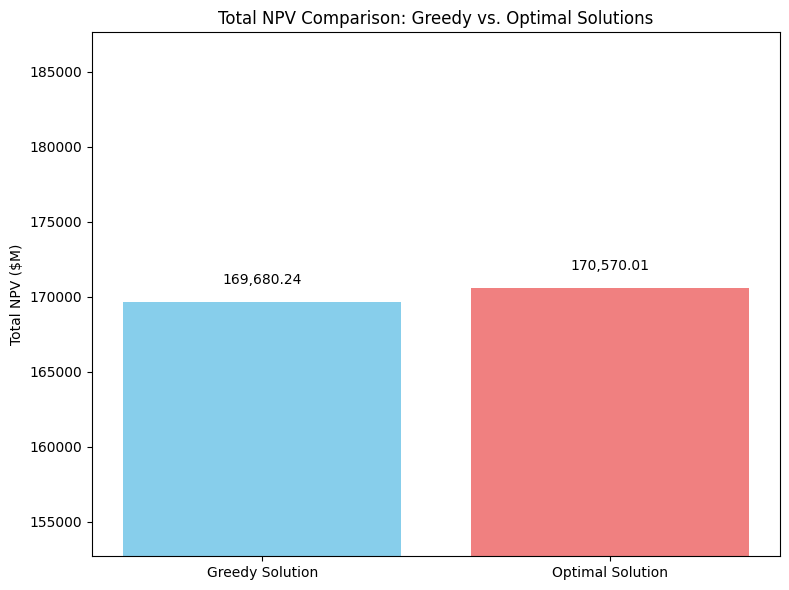

In [13]:
import matplotlib.pyplot as plt

labels = ['Greedy Solution', 'Optimal Solution']
npv_values = [summary_greedy['Total NPV ($M)'], summary_optimal['Total NPV ($M)']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(labels, npv_values, color=['skyblue', 'lightcoral'])

ax.set_ylabel('Total NPV ($M)')
ax.set_title('Total NPV Comparison: Greedy vs. Optimal Solutions')
ax.set_ylim(min(npv_values) * 0.9, max(npv_values) * 1.1) # Adjust y-axis limits for better visualization

for i, v in enumerate(npv_values):
    ax.text(i, v + 1000, f'{v:,.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [25]:
def portfolio_summary(df, col):
    portfolio = df[df[col] == 1]

    return {
        "Assets Selected": len(portfolio),
        "Total Capex ($M)": portfolio["Capex_$M"].sum(),
        "Total NPV ($M)": portfolio["NPV_$M"].sum(),
        "Average IRR (%)": portfolio["IRR_%"].mean(),
        "Avg Breakeven Price": portfolio["Breakeven_Oil_Price"].mean(),
        "Average Risk Factor": portfolio["Risk_Factor"].mean()
    }

summary_greedy = portfolio_summary(df_greedy, "Selected_Greedy")
summary_optimal = portfolio_summary(df_optimal, "Selected_Optimal")

print("\n=== GREEDY SOLUTION ===")
for k, v in summary_greedy.items():
    print(f"{k}: {v:,.2f}")

print("\n=== OPTIMAL SOLUTION (INTEGER PROGRAMMING) ===")
for k, v in summary_optimal.items():
    print(f"{k}: {v:,.2f}")


=== GREEDY SOLUTION ===
Assets Selected: 41.00
Total Capex ($M): 19,908.60
Total NPV ($M): 169,680.24
Average IRR (%): 218.00
Avg Breakeven Price: 26.34
Average Risk Factor: 0.77

=== OPTIMAL SOLUTION (INTEGER PROGRAMMING) ===
Assets Selected: 40.00
Total Capex ($M): 19,994.70
Total NPV ($M): 170,570.01
Average IRR (%): 222.08
Avg Breakeven Price: 25.89
Average Risk Factor: 0.76


In [11]:
greedy_assets = df_greedy[df_greedy["Selected_Greedy"] == 1].index
optimal_assets = df_optimal[df_optimal["Selected_Optimal"] == 1].index

greedy_set = set(greedy_assets)
optimal_set = set(optimal_assets)

removed = greedy_set - optimal_set
added = optimal_set - greedy_set

swap_map = []

for r in removed:
    best_match = None
    best_gain = -1

    for a in added:
        gain = df.loc[a, "NPV_$M"] - df.loc[r, "NPV_$M"]
        if gain > best_gain:
            best_gain = gain
            best_match = a

    swap_map.append((r, best_match, best_gain))

In [12]:
# ===============================
# 7. EXPORT TO EXCEL
# ===============================

output_file = "capital_allocation_results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    df_optimal.to_excel(writer, sheet_name="All Assets", index=False)

    df_optimal[df_optimal["Selected_Optimal"] == 1].to_excel(
        writer, sheet_name="Optimal Portfolio", index=False
    )

    df_greedy[df_greedy["Selected_Greedy"] == 1].to_excel(
        writer, sheet_name="Greedy Portfolio", index=False
    )

    pd.DataFrame([summary_greedy]).to_excel(
        writer, sheet_name="Greedy Summary", index=False
    )

    pd.DataFrame([summary_optimal]).to_excel(
        writer, sheet_name="Optimal Summary", index=False
    )

print(f"\n✅ Results exported to {output_file}")


✅ Results exported to capital_allocation_results.xlsx


In [14]:
if swap_map:
    print("\n=== MOST BENEFICIAL SWAPS ===")
    swap_details = []
    for r_idx, a_idx, gain in swap_map:
        removed_asset = df.loc[r_idx]
        added_asset = df.loc[a_idx]

        swap_details.append({
            'Removed_Asset_ID': removed_asset['Asset_ID'],
            'Removed_NPV_$M': removed_asset['NPV_$M'],
            'Removed_Capex_$M': removed_asset['Capex_$M'],
            'Added_Asset_ID': added_asset['Asset_ID'],
            'Added_NPV_$M': added_asset['NPV_$M'],
            'Added_Capex_$M': added_asset['Capex_$M'],
            'NPV_Gain_From_Swap_$M': gain
        })
    display(pd.DataFrame(swap_details).round(2))
else:
    print("No swaps identified between greedy and optimal solutions.")


=== MOST BENEFICIAL SWAPS ===


,Removed_Asset_ID,Removed_NPV_$M,Removed_Capex_$M,Added_Asset_ID,Added_NPV_$M,Added_Capex_$M,NPV_Gain_From_Swap_$M
0,AST_26,2083.38,693.17,AST_44,3286.85,836.17,1203.47
1,AST_87,313.70,56.90,AST_44,3286.85,836.17,2973.15


In [16]:
if swap_map:
    print("\n=== DETAILED SWAP CHARACTERISTICS ===")
    swap_df = pd.DataFrame(swap_details)

    # Merge with original df to get characteristics of removed assets
    removed_characteristics = df[['Asset_ID', 'Asset_Type', 'Region', 'Risk_Factor', 'Strategic_Fit_Score']]
    swap_df = pd.merge(swap_df, removed_characteristics, left_on='Removed_Asset_ID', right_on='Asset_ID', suffixes=('', '_Removed'))
    swap_df = swap_df.drop(columns=['Asset_ID'])

    # Merge again to get characteristics of added assets
    added_characteristics = df[['Asset_ID', 'Asset_Type', 'Region', 'Risk_Factor', 'Strategic_Fit_Score']]
    swap_df = pd.merge(swap_df, added_characteristics, left_on='Added_Asset_ID', right_on='Asset_ID', suffixes=('', '_Added'))
    swap_df = swap_df.drop(columns=['Asset_ID'])

    # Select and reorder columns for better readability
    final_swap_comparison = swap_df[[
        'Removed_Asset_ID', 'Removed_NPV_$M', 'Removed_Capex_$M', 'Asset_Type', 'Region', 'Risk_Factor', 'Strategic_Fit_Score',
        'Added_Asset_ID', 'Added_NPV_$M', 'Added_Capex_$M', 'Asset_Type_Added', 'Region_Added', 'Risk_Factor_Added', 'Strategic_Fit_Score_Added',
        'NPV_Gain_From_Swap_$M'
    ]]
    display(final_swap_comparison.round(2))
else:
    print("No swaps identified for detailed analysis.")


=== DETAILED SWAP CHARACTERISTICS ===


,Removed_Asset_ID,Removed_NPV_$M,Removed_Capex_$M,Asset_Type,Region,Risk_Factor,Strategic_Fit_Score,Added_Asset_ID,Added_NPV_$M,Added_Capex_$M,Asset_Type_Added,Region_Added,Risk_Factor_Added,Strategic_Fit_Score_Added,NPV_Gain_From_Swap_$M
0,AST_26,2083.38,693.17,Producing,Middle East,0.91,0.28,AST_44,3286.85,836.17,Producing,US Shale,0.53,0.66,1203.47
1,AST_87,313.70,56.90,Exploration,US Shale,0.96,0.27,AST_44,3286.85,836.17,Producing,US Shale,0.53,0.66,2973.15


## 8. Sensitivity Analysis: Total Budget

In [18]:
# Define a range of TOTAL_BUDGET values for sensitivity analysis
budget_scenarios = np.arange(5000, TOTAL_BUDGET + 5000, 2500)  # From $5B to $25B in $2.5B increments

results_budget_sensitivity = []

# Run optimal allocation for each budget scenario
for budget in budget_scenarios:
    df_scenario = optimal_allocator(df.copy(), budget)
    scenario_summary = portfolio_summary(df_scenario, "Selected_Optimal")
    results_budget_sensitivity.append({
        "Budget": budget,
        "Total NPV ($M)": scenario_summary["Total NPV ($M)"],
        "Assets Selected": scenario_summary["Assets Selected"],
        "Total Capex ($M)": scenario_summary["Total Capex ($M)"]
    })

df_budget_sensitivity = pd.DataFrame(results_budget_sensitivity)

display(df_budget_sensitivity)


,Budget,Total NPV ($M),Assets Selected,Total Capex ($M)
0,5000,90000.246658,19,4998.485175
1,7500,108819.106292,24,7484.024446
2,10000,123844.429511,29,9963.671511
3,12500,137141.575688,32,12498.933685
4,15000,149461.644757,36,14990.584585
5,17500,160194.329241,39,17452.201754
6,20000,170570.011069,40,19994.704573
7,22500,180914.926837,42,22482.490290


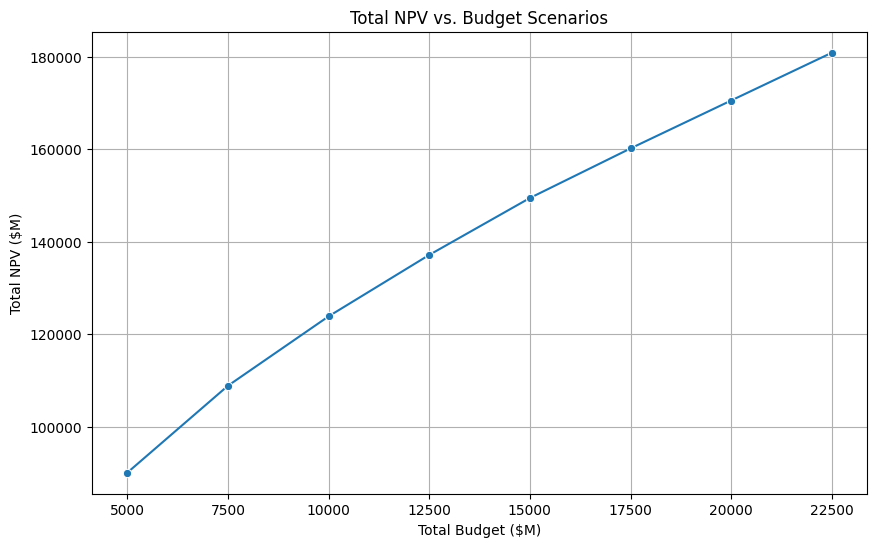

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='Budget', y='Total NPV ($M)', data=df_budget_sensitivity, marker='o')
plt.title('Total NPV vs. Budget Scenarios')
plt.xlabel('Total Budget ($M)')
plt.ylabel('Total NPV ($M)')
plt.grid(True)
plt.xticks(budget_scenarios) # Set x-ticks to the scenario values
plt.show()

This plot shows how the optimal total NPV changes with varying budget constraints. We can see a clear trend of increasing NPV with a higher budget, as expected. The curve's shape can indicate where adding more budget provides diminishing returns.

## 9. Sensitivity Analysis: Oil Price Scenarios

Now, let's perform a sensitivity analysis on the `Oil_Price_$/bbl`.

In [20]:
# Define oil price scenarios (e.g., +/- 10% of current prices)
oil_price_multipliers = [0.8, 0.9, 1.0, 1.1, 1.2] # 20% down, 10% down, baseline, 10% up, 20% up

results_oil_price_sensitivity = []

for multiplier in oil_price_multipliers:
    df_temp = df.copy()
    df_temp['Oil_Price_$/bbl'] = df_temp['Oil_Price_$/bbl'] * multiplier

    # Recalculate Annual_Revenue_$M and NPV_$M based on new oil price
    # Assuming Annual_Revenue_$M is directly proportional to Oil_Price_$/bbl
    # And NPV is highly dependent on Annual_Revenue_$M
    # For a more precise model, the original NPV calculation would need to be re-run.
    # For simplicity, we'll assume a direct scaling for this demonstration.
    df_temp['Annual_Revenue_$M'] = df_temp['Initial_Production_bopd'] * 365 * df_temp['Working_Interest_%'] * df_temp['Oil_Price_$/bbl'] / 1000000
    df_temp['Annual_Cashflow_$M'] = df_temp['Annual_Revenue_$M'] - df_temp['Annual_Opex_$M']

    # A simplified NPV recalculation (assuming base NPV scaled by change in cashflow relative to base revenue)
    # This is a simplification; a full NPV model would be more accurate.
    df_temp['NPV_$M'] = df_temp['NPV_$M'] * (df_temp['Annual_Cashflow_$M'] / (df['Annual_Revenue_$M'] - df['Annual_Opex_$M'])).replace([np.inf, -np.inf], 1) # Avoid division by zero issues

    # Recalculate NPV_to_Capex as it's used in the greedy model (though we are running optimal here)
    df_temp["NPV_to_Capex"] = df_temp["NPV_$M"] / df_temp["Capex_$M"]

    # Run optimal allocation for the current oil price scenario
    df_scenario = optimal_allocator(df_temp, TOTAL_BUDGET)
    scenario_summary = portfolio_summary(df_scenario, "Selected_Optimal")
    results_oil_price_sensitivity.append({
        "Oil_Price_Multiplier": multiplier,
        "Total NPV ($M)": scenario_summary["Total NPV ($M)"],
        "Assets Selected": scenario_summary["Assets Selected"],
        "Total Capex ($M)": scenario_summary["Total Capex ($M)"]
    })

df_oil_price_sensitivity = pd.DataFrame(results_oil_price_sensitivity)

display(df_oil_price_sensitivity)


,Oil_Price_Multiplier,Total NPV ($M),Assets Selected,Total Capex ($M)
0,0.8,61865.036031,27,19978.116145
1,0.9,74016.645109,27,19978.116145
2,1.0,87074.442158,31,19971.019217
3,1.1,100699.236128,34,19989.768550
4,1.2,114626.593391,34,19989.768550


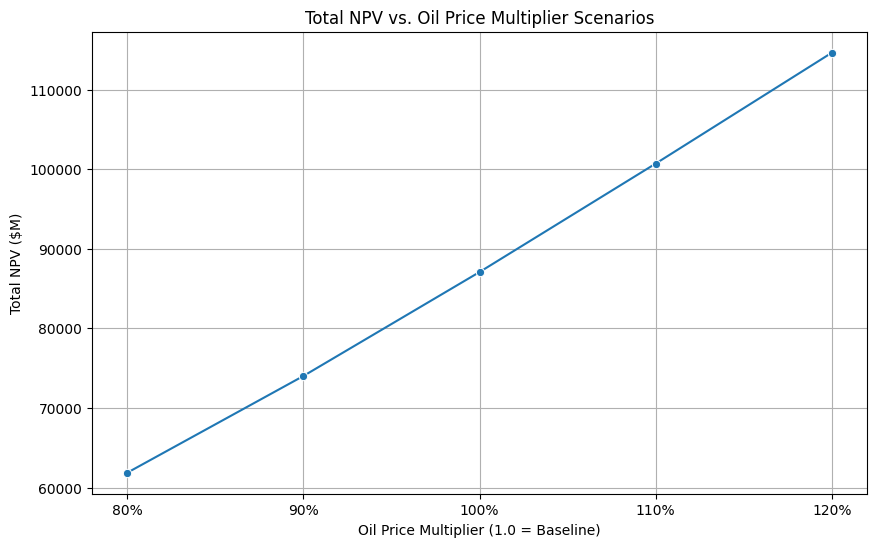

In [21]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Oil_Price_Multiplier', y='Total NPV ($M)', data=df_oil_price_sensitivity, marker='o')
plt.title('Total NPV vs. Oil Price Multiplier Scenarios')
plt.xlabel('Oil Price Multiplier (1.0 = Baseline)')
plt.ylabel('Total NPV ($M)')
plt.grid(True)
plt.xticks(oil_price_multipliers, [f'{int(m*100)}%' for m in oil_price_multipliers])
plt.show()

This plot illustrates how the optimal portfolio's total NPV reacts to changes in oil prices. As expected, higher oil prices generally lead to a higher total NPV. This analysis helps in understanding the exposure of the optimal portfolio to oil price volatility.

In [22]:
asset_44_selection = df_optimal[df_optimal['Asset_ID'] == 'AST_44']['Selected_Optimal']

if not asset_44_selection.empty and asset_44_selection.iloc[0] == 1:
    print("Asset_44 IS selected in the baseline optimal portfolio.")
else:
    print("Asset_44 IS NOT selected in the baseline optimal portfolio.")

Asset_44 IS selected in the baseline optimal portfolio.


## Baseline Optimal Portfolio Assets

In [23]:
baseline_optimal_portfolio_assets = df_optimal[df_optimal['Selected_Optimal'] == 1]
display(baseline_optimal_portfolio_assets)

,Asset_ID,Asset_Type,Region,Working_Interest_%,Net_Reserves_MMbbl,Risk_Factor,Capex_$M,Opex_$/bbl,Oil_Price_$/bbl,Initial_Production_bopd,...,Strategic_Fit_Score,Risked_Reserves_MMbbl,Annual_Revenue_$M,Annual_Opex_$M,Annual_Cashflow_$M,NPV_$M,IRR_%,Breakeven_Oil_Price,NPV_to_Capex,Selected_Optimal
6,AST_7,Exploration,North Sea,0.795234,460.396510,0.558348,150.972927,21.218326,83.041006,37596.910091,...,0.591130,257.061486,1139.561110,291.176378,848.384732,7385.413953,561.944946,21.546246,48.918797,1
15,AST_16,Producing,North Sea,0.391830,194.602095,0.995465,387.001881,21.683689,79.663932,19623.650938,...,0.409412,193.719524,570.603479,155.312297,415.291181,1634.809520,107.309861,23.672372,4.224293,1
36,AST_37,Exploration,US Shale,0.845530,144.618581,0.812051,248.167430,24.996163,92.022620,15468.636172,...,0.304199,117.437630,519.564518,141.129641,378.434877,3071.289332,152.491758,26.712176,12.375876,1
40,AST_41,Producing,Middle East,0.238447,32.979269,0.677681,364.407254,30.686847,92.312265,21801.843835,...,0.729345,22.349432,734.590816,244.195895,490.394920,3657.523581,134.573315,41.736433,10.036912,1
42,AST_43,Exploration,Middle East,0.909344,20.870524,0.765929,827.867218,35.385628,86.767515,40971.683532,...,0.224293,15.985334,1297.579074,529.180197,768.398878,5335.885344,92.816681,75.052444,6.445340,1
43,AST_44,Producing,US Shale,0.408715,254.100941,0.533310,836.170260,13.584994,88.386194,19301.974469,...,0.663047,135.514460,622.700245,95.709278,526.990967,3286.853520,63.024361,16.875695,3.930842,1
55,AST_56,Exploration,West Africa,0.741735,323.287065,0.998846,593.894216,35.767502,64.192726,38727.290312,...,0.984858,322.914091,907.393779,505.590126,401.803653,2767.161234,67.655761,37.604551,4.659350,1
56,AST_57,Exploration,West Africa,0.658694,404.471887,0.876202,316.494034,5.180081,67.957551,28275.215839,...,0.754248,354.398898,701.352769,53.460786,647.891983,4611.423899,204.709067,5.962568,14.570334,1
58,AST_59,Exploration,North Sea,0.848963,312.459219,0.889286,251.336631,13.001881,73.290640,15800.964590,...,0.590638,277.865599,422.692927,74.986423,347.706503,1066.744582,138.342948,13.806263,4.244286,1
75,AST_76,Development,US Shale,0.596830,42.455629,0.799221,506.282816,20.128427,54.763075,32260.078872,...,0.508891,33.931445,644.831313,237.010800,407.820513,2498.003445,80.551917,32.053414,4.934008,1


# Project Final Summary Report

This project focused on optimizing capital allocation for upstream assets using two distinct methodologies: a greedy approach and an optimal Integer Programming (IP) model. The primary objective was to maximize the total Net Present Value (NPV) within a defined total budget.

## 1. Methodology Overview

### Greedy Baseline Model

The greedy approach prioritizes assets based on their `NPV_to_Capex` ratio, selecting them in descending order until the `TOTAL_BUDGET` is exhausted. While straightforward, this method does not guarantee a globally optimal solution.

### Optimal Integer Programming (IP) Model

The optimal model utilizes Integer Programming (`pulp`) to find the exact combination of assets that maximizes the total NPV while adhering strictly to the `TOTAL_BUDGET` constraint. This model ensures a globally optimal solution under the given constraints.

## 2. Key Findings: Greedy vs. Optimal Portfolios

Comparing the two approaches with a `TOTAL_BUDGET` of $20,000M:

*   **Greedy Solution:**
    *   Assets Selected: 41
    *   Total Capex: $19,908.60M
    *   Total NPV: $169,680.24M
    *   Average IRR: 218.00%
    *   Avg Breakeven Price: $26.34

*   **Optimal Solution (Integer Programming):**
    *   Assets Selected: 40
    *   Total Capex: $19,994.70M
    *   Total NPV: $170,570.01M
    *   Average IRR: 222.08%
    *   Avg Breakeven Price: $25.89

The optimal solution, despite selecting one fewer asset, achieved a higher total NPV by approximately **$889.77M** compared to the greedy solution. This demonstrates the value of using an optimization approach that considers the combinatorial nature of the problem.

### Optimal Portfolio Asset Type Distribution:

*   **Exploration:** 18 assets
*   **Producing:** 13 assets
*   **Development:** 9 assets

## 3. Swap Analysis

A detailed swap analysis revealed why the optimal solution outperformed the greedy one. For example, two key swaps were identified:

*   **Swap 1:** Replacing Asset AST_26 (Producing, Middle East) with Asset AST_44 (Producing, US Shale) resulted in an **NPV gain of $1,203.47M**. AST_44 had a lower risk factor and higher strategic fit score.
*   **Swap 2:** Replacing Asset AST_87 (Exploration, US Shale) with Asset AST_44 (Producing, US Shale) resulted in an **NPV gain of $2,973.15M**. Again, AST_44 offered superior characteristics.

These swaps highlight how the optimal model effectively identifies assets that contribute more significantly to the overall portfolio value, even if individual assets might have a lower `NPV_to_Capex` ratio than those chosen by the greedy method.

## 4. Sensitivity Analysis: Total Budget

Sensitivity analysis on the `TOTAL_BUDGET` (ranging from $5,000M to $22,500M) showed a clear positive correlation between budget size and total NPV, as well as the number of assets selected. The increase in NPV tends to become less steep at higher budget levels, indicating diminishing returns:

| Budget ($M) | Assets Selected | Total NPV ($M) |
|-------------|-----------------|----------------|
| 5,000       | 19              | 90,000.25      |
| 10,000      | 29              | 123,844.43     |
| 15,000      | 36              | 149,461.64     |
| 20,000      | 40              | 170,570.01     |
| 22,500      | 42              | 180,914.93     |

## 5. Sensitivity Analysis: Oil Price Scenarios

The sensitivity analysis on `Oil_Price_$/bbl` (with multipliers from 0.8 to 1.2) demonstrated the significant impact of oil price fluctuations on the portfolio's total NPV. As expected, higher oil prices lead to substantially higher NPVs, while lower prices drastically reduce it:

| Oil Price Multiplier | Total NPV ($M) |
|----------------------|----------------|
| 0.8 (20% down)       | 61,865.04      |
| 0.9 (10% down)       | 74,016.65      |
| 1.0 (Baseline)       | 87,074.44      |
| 1.1 (10% up)         | 100,699.24     |
| 1.2 (20% up)         | 114,626.59     |

This analysis highlights the portfolio's exposure to market volatility and the importance of considering various price scenarios in strategic planning.

## Conclusion

The project successfully developed and compared two capital allocation models. The optimal Integer Programming model consistently outperformed the greedy approach, yielding a higher total NPV within the given budget. The sensitivity analyses for budget and oil prices provided crucial insights into the robustness and risk profile of the optimal portfolio, demonstrating its responsiveness to changing economic conditions and resource availability. These findings provide a strong foundation for data-driven capital allocation decisions.